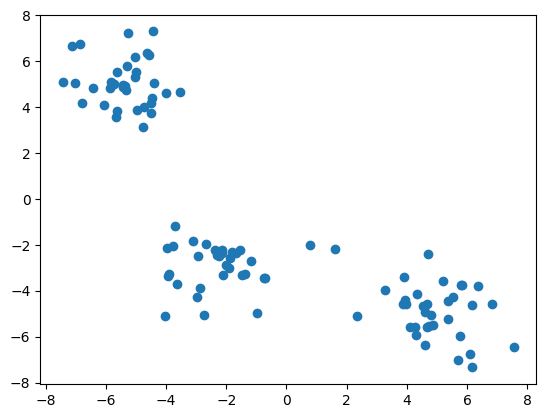

In [21]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

centroids = [(-5,5),(5,-5),(-2.5,-3.0)]
cluster_std= [1,1,1]

X,y = make_blobs(n_samples=100, cluster_std=cluster_std, centers=centroids, n_features=2,random_state=2)

plt.scatter(X[:,0],X[:,1])
plt.show()

In [25]:
import random
import numpy as np

class KMeans:
  def __init__(self, n_clusters=2, max_iter=100):
    self.n_clusters = n_clusters
    self.max_iter = max_iter
    self.centroids = None

  def fit_predict(self,X):
    random_index = random.sample(range(0, X.shape[0]), self.n_clusters)
    self.centroids = X[random_index]

    for i in range(self.max_iter):
      # assign clusters
      cluster_group = self.assign_clusters(X)
      old_centroids = self.centroids
      # move centroids
      self.centroids = self.move_clusters(X, cluster_group)
      # check finish
      if(old_centroids == self.centroids).all():
        break

    return cluster_group

  def assign_clusters(self,X):
    cluster_group = []
    distances = []

    for row in X:
      for centroid in self.centroids:
        distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))
      min_distance = min(distances)
      index_pos = distances.index(min_distance)
      cluster_group.append(index_pos)
      distances.clear()

    return np.array(cluster_group)

  def move_clusters(self, X, cluster_group):
    new_centroids = []
    cluster_types = np.unique(cluster_group)

    for t in cluster_types:
      new_centroids.append(X[cluster_group == t].mean(axis=0))

    return np.array(new_centroids)

In [34]:
km = KMeans(n_clusters=3, max_iter=100)
y_means = km.fit_predict(X)

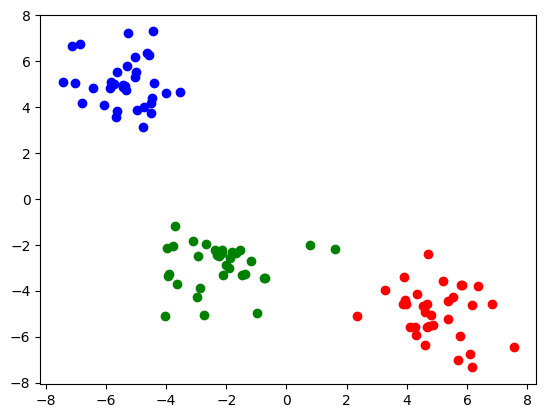

In [35]:
plt.scatter(X[y_means == 0,0], X[y_means == 0,1], color='red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1], color='green')
plt.scatter(X[y_means == 2,0], X[y_means == 2,1], color='blue')

plt.show()